# Multi Class Chest Radiography with ResNet50 and Grad-CAM. Full Pipeline in One Notebook

**Project:** Multimodal Explainable AI for Chest Radiology, Master 2 ISI
**Scope:** preprocessing, ResNet50 training, full multi class evaluation and Grad-CAM explanation in a single reproducible file, extending the binary RSNA pipeline to a four class problem. Every methodological choice is justified by an article of the SOTA table.

**Dataset: COVID-19 Radiography Database.** This dataset appears in the SOTA table through the Ensemble-CAM paper, Frontiers in Big Data 2024, which uses it as one of its three evaluation datasets. It contains 21,165 chest radiographs in four classes, COVID, Lung Opacity, Normal and Viral Pneumonia, is hosted on Kaggle at about eight hundred megabytes, and turns the task into true multi class classification as requested for this stage of the project.

**Backbone: ResNet50 pretrained on ImageNet,** kept identical to the RSNA notebook so the binary and multi class results are directly comparable, and matching the baseline of the MDPI Information 2025 paper of the SOTA table.

**Kaggle setup.** Add Input, Datasets, search `COVID-19 Radiography Database` by Tawsifur Rahman, enable GPU T4 and Internet.

**Outputs saved in `/kaggle/working`:** frozen splits, best weights, metrics json, per image predictions, evaluation figures and Grad-CAM figures.


## Part 1. Setup and reproducibility

Identical seed policy to the previous notebooks of the project, a fixed and documented seed applied to every random generator, since reproducibility is a project deliverable.

In [1]:
import os
import glob
import json
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "/kaggle/working"
print("Device:", DEVICE)

Device: cpu


## Part 2. Preprocessing step one, locate the data and build the index

The dataset stores each class in its own folder of png images. The root is resolved by searching for one known class folder so the notebook survives mount name changes. One row per image is built with its path, its class name and its integer target.

In [2]:
covid_dirs = glob.glob("/kaggle/input/**/COVID/images", recursive=True)
DATA_ROOT = os.path.dirname(os.path.dirname(covid_dirs[0]))
print("Data root:", DATA_ROOT)

CLASSES = ["Normal", "Lung_Opacity", "COVID", "Viral Pneumonia"]
class_to_target = {c: i for i, c in enumerate(CLASSES)}

rows = []
for cls in CLASSES:
    folder = os.path.join(DATA_ROOT, cls, "images")
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(".png"):
            rows.append({"filepath": os.path.join(folder, fname),
                         "filename": fname,
                         "class": cls,
                         "target": class_to_target[cls]})

table = pd.DataFrame(rows)
print(table["class"].value_counts())
print("Total images:", len(table))

Data root: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
class
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64
Total images: 21165


## Part 3. Preprocessing step two, stratified split and its stated limitation

Unlike RSNA this dataset publishes no patient identifier, so a patient level split is impossible. The split is therefore stratified at the image level with the 70 10 20 proportions of the Scientific Reports 2025 and MedVAG papers of the SOTA table. This is exactly the limitation the PLOS ONE 2024 authors acknowledge for their own protocol, and it must be stated in the thesis as a known threat to validity of this dataset, with RSNA providing the leak free counterpart in the project.

In [3]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(table, test_size=0.30,
                                     stratify=table["target"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=2/3,
                                   stratify=temp_df["target"], random_state=SEED)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, len(d))
    print(d["class"].value_counts().to_dict())

cols = ["filepath", "filename", "class", "target"]
train_df[cols].to_csv(os.path.join(OUTPUT_DIR, "covid_train.csv"), index=False)
val_df[cols].to_csv(os.path.join(OUTPUT_DIR, "covid_val.csv"), index=False)
test_df[cols].to_csv(os.path.join(OUTPUT_DIR, "covid_test.csv"), index=False)
print("Splits frozen on disk")

train 14815
{'Normal': 7134, 'Lung_Opacity': 4208, 'COVID': 2531, 'Viral Pneumonia': 942}
val 2116
{'Normal': 1019, 'Lung_Opacity': 601, 'COVID': 362, 'Viral Pneumonia': 134}
test 4234
{'Normal': 2039, 'Lung_Opacity': 1203, 'COVID': 723, 'Viral Pneumonia': 269}
Splits frozen on disk


## Part 4. Preprocessing step three, visual verification

Three images per class confirm correct decoding and let the reader observe the visual signatures, diffuse bilateral opacities for COVID, focal opacities for Lung Opacity, clearer fields for Normal.

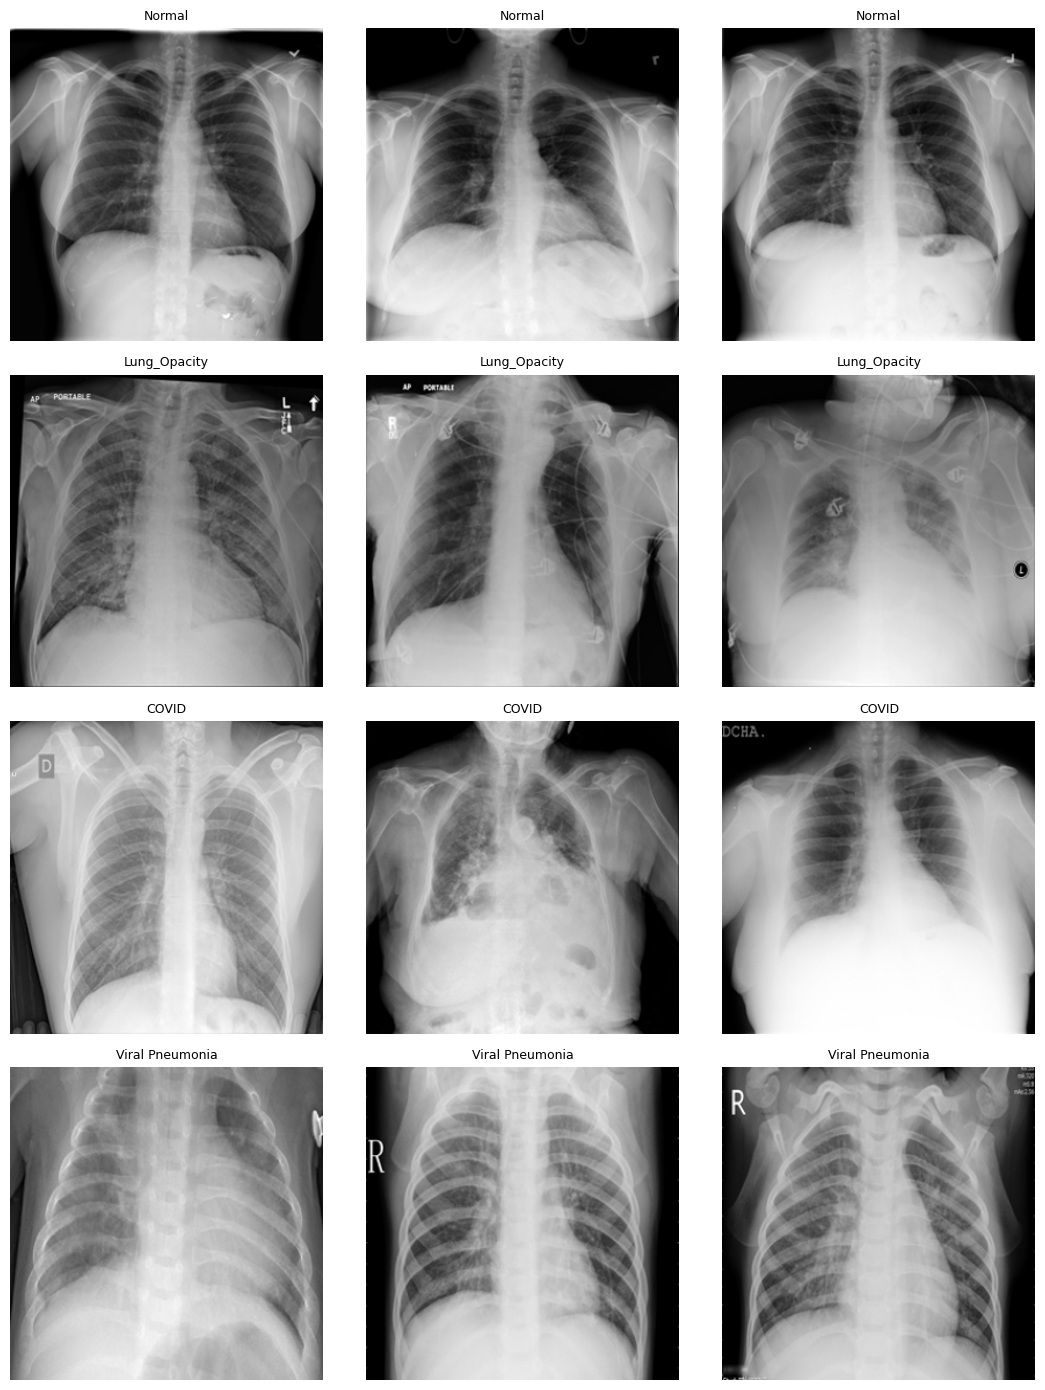

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(11, 14))
for row_idx, cls in enumerate(CLASSES):
    sample = train_df[train_df["class"] == cls].sample(3, random_state=SEED)
    for col_idx, (_, r) in enumerate(sample.iterrows()):
        img = Image.open(r["filepath"]).convert("L")
        axes[row_idx, col_idx].imshow(img, cmap="gray")
        axes[row_idx, col_idx].set_title(cls, fontsize=9)
        axes[row_idx, col_idx].axis("off")
plt.tight_layout()
plt.show()

## Part 5. Preprocessing step four, transformations from the SOTA papers

Same policy as the RSNA notebook and same sources. Resize to 224 by 224 and ImageNet normalization required by the pretrained backbone, augmentation with rotation of fifteen degrees, horizontal flip and zoom following the exact parameters of the MDPI Information 2025 paper, training set only.

In [5]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(15),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class CovidDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        return self.transform(img), torch.tensor(row["target"], dtype=torch.long)

BATCH_SIZE = 32
train_loader = DataLoader(CovidDataset(train_df, train_transform), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(CovidDataset(val_df, eval_transform), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(CovidDataset(test_df, eval_transform), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)
print("Batches per training epoch:", len(train_loader))

Batches per training epoch: 463


## Part 6. Model, ResNet50 with a four class head

Same transfer learning recipe as the RSNA notebook, justified by the same SOTA papers. The head becomes a four class layer, the loss is the categorical cross entropy of the Ensemble-CAM paper with inverse frequency class weights compensating the imbalance, Viral Pneumonia being seven times rarer than Normal, the same motivation as the pos weight of the Scientific Reports 2025 paper. Adam with learning rate 1e-4 and ReduceLROnPlateau follow Nature Machine Intelligence 2022 and PLOS ONE 2024.

In [6]:
NUM_CLASSES = 4
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

counts = train_df["target"].value_counts().sort_index().values
class_weights = torch.tensor(len(train_df) / (NUM_CLASSES * counts),
                             dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(CLASSES, class_weights.cpu().numpy().round(3))))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                       factor=0.1, patience=2)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 133MB/s]


Class weights: {'Normal': np.float32(0.519), 'Lung_Opacity': np.float32(0.88), 'COVID': np.float32(1.463), 'Viral Pneumonia': np.float32(3.932)}


## Part 7. Training with early stopping

The monitored quantity becomes the macro F1, the selection metric of the Scientific Reports 2025 multi label paper of the SOTA table, because in a multi class problem with imbalance a plain accuracy would be dominated by the Normal class. The cap of ten epochs with patience three keeps the same budget logic as the RSNA notebook, upper bounds under early stopping following PLOS ONE 2024 and Ensemble-CAM, sized for the Kaggle quota.

In [7]:
from sklearn.metrics import f1_score

def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.set_grad_enabled(train_mode):
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(targets)
            all_labels.extend(targets.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1).detach().cpu().numpy())
    return (total_loss / len(loader.dataset),
            np.array(all_labels), np.array(all_probs))

EPOCHS = 10
PATIENCE = 3
CKPT = os.path.join(OUTPUT_DIR, "resnet50_covid_best.pth")
best_f1, without_improvement = 0.0, 0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, _, _ = run_epoch(train_loader, True)
    val_loss, val_labels, val_probs = run_epoch(val_loader, False)
    val_preds = val_probs.argmax(axis=1)
    val_f1 = f1_score(val_labels, val_preds, average="macro")
    scheduler.step(val_f1)
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "val_loss": val_loss, "val_macro_f1": val_f1})
    print(f"epoch {epoch}  train_loss {train_loss:.4f}  val_loss {val_loss:.4f}"
          f"  val_macro_f1 {val_f1:.4f}  minutes {round((time.time() - start) / 60, 1)}")
    if val_f1 > best_f1:
        best_f1, without_improvement = val_f1, 0
        torch.save(model.state_dict(), CKPT)
        print("new best model saved")
    else:
        without_improvement += 1
        if without_improvement >= PATIENCE:
            print("early stopping")
            break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 1  train_loss 0.4169  val_loss 0.3723  val_macro_f1 0.8085  minutes 89.6
new best model saved


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 2  train_loss 0.2138  val_loss 0.2048  val_macro_f1 0.9267  minutes 92.4
new best model saved


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 3  train_loss 0.1784  val_loss 0.1695  val_macro_f1 0.9189  minutes 91.8


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 4  train_loss 0.1498  val_loss 0.2774  val_macro_f1 0.8610  minutes 97.8


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 5  train_loss 0.1314  val_loss 0.1861  val_macro_f1 0.9130  minutes 103.3
early stopping


## Part 8. Multi class evaluation on the held out test set

The metric set extends the binary protocol to multi class the standard way. Overall accuracy, then macro averaged precision, recall and F1 so every class weighs equally despite the imbalance, per class detail through the classification report, and the one versus rest macro AUC that generalizes the AUC of the PLOS ONE and MDPI protocols. The confusion matrix shows which pathologies get confused, and the clinically interesting confusions here are COVID against Viral Pneumonia and Lung Opacity.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


accuracy: 0.9313
macro_precision: 0.9239
macro_recall: 0.9384
macro_f1: 0.9297
macro_auc_ovr: 0.9913

                 precision    recall  f1-score   support

         Normal     0.9211    0.9564    0.9384      2039
   Lung_Opacity     0.9560    0.8670    0.9093      1203
          COVID     0.9501    0.9488    0.9495       723
Viral Pneumonia     0.8684    0.9814    0.9215       269

       accuracy                         0.9313      4234
      macro avg     0.9239    0.9384    0.9297      4234
   weighted avg     0.9326    0.9313    0.9310      4234



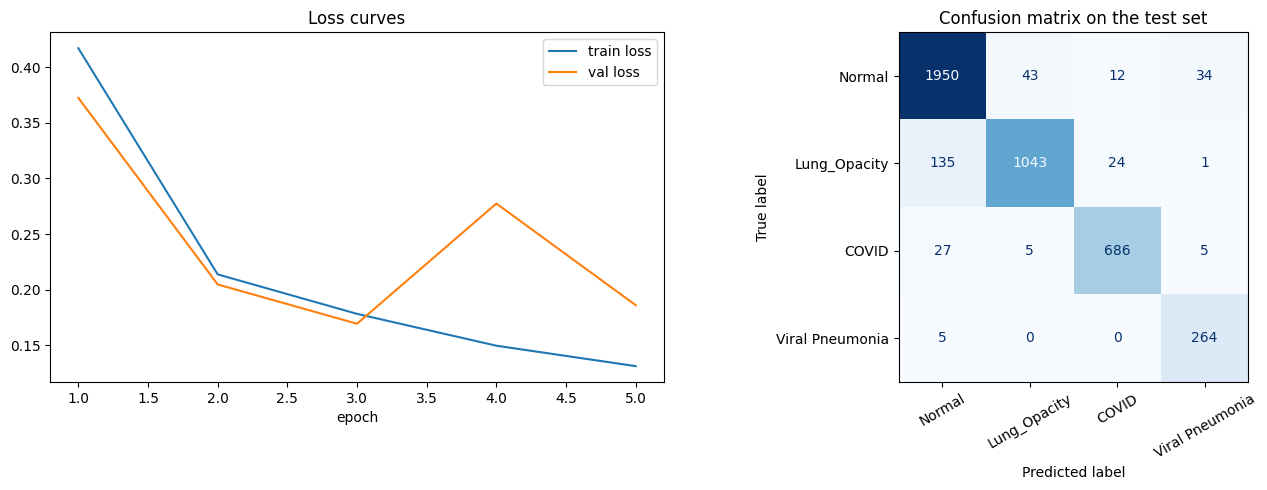

In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

model.load_state_dict(torch.load(CKPT))
_, test_labels, test_probs = run_epoch(test_loader, False)
test_preds = test_probs.argmax(axis=1)

metrics = {
    "accuracy": accuracy_score(test_labels, test_preds),
    "macro_precision": precision_score(test_labels, test_preds, average="macro"),
    "macro_recall": recall_score(test_labels, test_preds, average="macro"),
    "macro_f1": f1_score(test_labels, test_preds, average="macro"),
    "macro_auc_ovr": roc_auc_score(test_labels, test_probs,
                                   multi_class="ovr", average="macro")
}
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print()
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

with open(os.path.join(OUTPUT_DIR, "covid_metrics.json"), "w") as f:
    json.dump({k: round(v, 4) for k, v in metrics.items()}, f, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hist = pd.DataFrame(history)
axes[0].plot(hist["epoch"], hist["train_loss"], label="train loss")
axes[0].plot(hist["epoch"], hist["val_loss"], label="val loss")
axes[0].legend()
axes[0].set_xlabel("epoch")
axes[0].set_title("Loss curves")

cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Blues", ax=axes[1],
                                                        colorbar=False, xticks_rotation=30)
axes[1].set_title("Confusion matrix on the test set")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "covid_resnet50_evaluation.png"), dpi=200,
            bbox_inches="tight")
plt.show()

out = test_df[["filename", "class", "target"]].copy()
for i, cls in enumerate(CLASSES):
    out[f"prob_{cls}"] = test_probs[:, i]
out["prediction"] = test_preds
out.to_csv(os.path.join(OUTPUT_DIR, "covid_test_predictions.csv"), index=False)

## Part 9. Grad-CAM explanation per class

Grad-CAM is applied following its original paper, Selvaraju and colleagues ICCV 2017, on the last convolutional block of ResNet50. The multi class setting adds an ability the binary notebooks did not have, class discriminative explanation, the founding property of Grad-CAM. For one image the heatmap of each of the four class scores can be compared, and a well behaved model should light different regions for different classes. Two figures are produced, one heatmap per class on correctly classified examples, and the four class heatmaps of one single COVID image.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


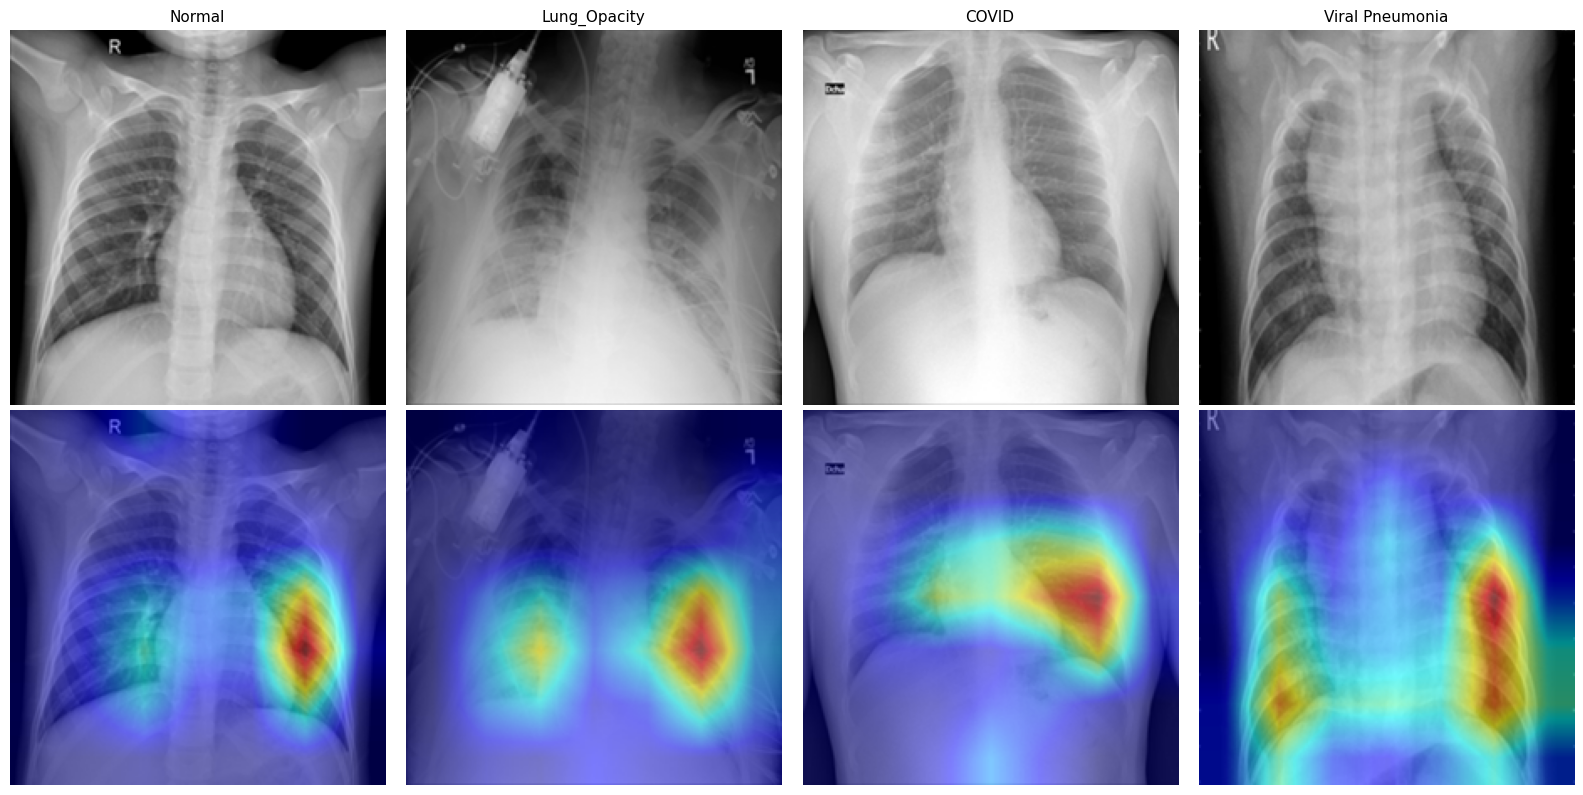

In [9]:
!pip install grad-cam --quiet
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

def load_for_cam(filepath):
    img = Image.open(filepath).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(DEVICE)
    display = np.array(img.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0
    return tensor, display

test_eval = test_df.reset_index(drop=True).copy()
test_eval["prediction"] = test_preds

# Figure one, one correctly classified example per class with its Grad-CAM
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for c, cls in enumerate(CLASSES):
    pool = test_eval[(test_eval["class"] == cls) &
                     (test_eval["prediction"] == class_to_target[cls])]
    row = pool.sample(1, random_state=SEED).iloc[0]
    tensor, display = load_for_cam(row["filepath"])
    heatmap = cam(input_tensor=tensor,
                  targets=[ClassifierOutputTarget(class_to_target[cls])])[0]
    axes[0, c].imshow(display)
    axes[0, c].set_title(cls, fontsize=11)
    axes[0, c].axis("off")
    axes[1, c].imshow(show_cam_on_image(display, heatmap, use_rgb=True))
    axes[1, c].axis("off")
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("Grad-CAM")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_per_class.png"), dpi=200, bbox_inches="tight")
plt.show()

## Part 10. Class discriminative heatmaps of one image

The same COVID image is explained four times, once against each class score. The heatmap of the predicted class should focus on the lesions while the heatmaps of the other classes should differ, which demonstrates the class discriminative property that made Grad-CAM the reference method and gives the thesis a figure the binary setting could not provide.

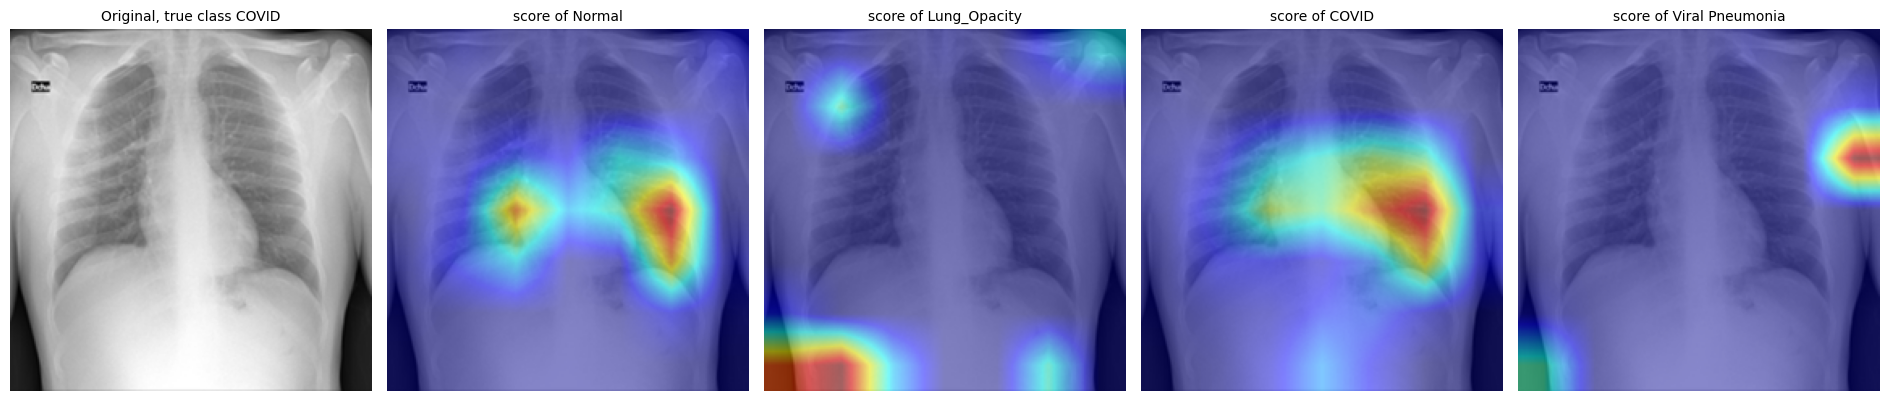

Final content of the working directory:
  __notebook__.ipynb
  covid_metrics.json
  covid_resnet50_evaluation.png
  covid_test.csv
  covid_test_predictions.csv
  covid_train.csv
  covid_val.csv
  gradcam_class_discriminative.png
  gradcam_per_class.png
  resnet50_covid_best.pth


In [10]:
row = test_eval[(test_eval["class"] == "COVID") &
                (test_eval["prediction"] == class_to_target["COVID"])].sample(
                1, random_state=SEED).iloc[0]
tensor, display = load_for_cam(row["filepath"])

fig, axes = plt.subplots(1, 5, figsize=(19, 4))
axes[0].imshow(display)
axes[0].set_title("Original, true class COVID", fontsize=10)
axes[0].axis("off")
for c, cls in enumerate(CLASSES):
    heatmap = cam(input_tensor=tensor,
                  targets=[ClassifierOutputTarget(class_to_target[cls])])[0]
    axes[c + 1].imshow(show_cam_on_image(display, heatmap, use_rgb=True))
    axes[c + 1].set_title(f"score of {cls}", fontsize=10)
    axes[c + 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_class_discriminative.png"), dpi=200,
            bbox_inches="tight")
plt.show()

print("Final content of the working directory:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" ", f)